In [1]:
# import torch.optim as optim
import pandas as pd
import numpy as np
import util_fun as uf
from cstm_models import build_mlp 

## Training Params

In [ ]:
# model parameters
LOOKBACK = 48   # 48 h of historical data for prediction
HORIZON = 24    # 24 h of prediction
N_FEATURES = 4  # Q_bar, P_bar, T_bar, H_bar
BATCH_SIZE = 1  
H_BAR_INDEX = 3 
EPSILON = 1e-6  # For numerical stability in normalization

In [3]:
train_df = pd.read_csv('dataset/one_station_train_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
test_df = pd.read_csv('dataset/one_station_test_data.csv',parse_dates=[0], index_col=0, dayfirst=True)
display(train_df.info())
display(test_df.info())

x_train, y_train = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)
x_test, y_test = uf.create_sequences(test_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX)

#Building datasets to be used by pytorch DataLoader
train_ds = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX)
test_ds  = uf.RollingNormTimeSeriesDataset(x_test, y_test, H_BAR_INDEX)

<class 'pandas.core.frame.DataFrame'>
Index: 59123 entries, 2009-01-01 00:00:00 to 2019-12-13 20:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   59123 non-null  float64
 1   P_bar   59123 non-null  float64
 2   T_bar   59123 non-null  float64
 3   H_bar   59123 non-null  float64
dtypes: float64(4)
memory usage: 2.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 17524 entries, 2008-01-01 00:00:00 to 2014-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Q_bar   17524 non-null  float64
 1   P_bar   17524 non-null  float64
 2   T_bar   17524 non-null  float64
 3   H_bar   17524 non-null  float64
dtypes: float64(4)
memory usage: 684.5+ KB


None

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 59064.
Total sequences created: 2461
 X shape: (2461, 48, 4), y shape: (2461, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 24
End of sufficient data at index 17472.
Total sequences created: 728
 X shape: (728, 48, 4), y shape: (728, 24)


In [4]:
# --- No-leakage sequences (step = LOOKBACK + HORIZON = 72) ---
x_train_72, y_train_72 = uf.create_sequences(train_df.values.astype(np.float32), LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)
x_test_72,  y_test_72  = uf.create_sequences(test_df.values.astype(np.float32),  LOOKBACK, HORIZON, H_BAR_INDEX, step=LOOKBACK+HORIZON)

train_ds_72 = uf.RollingNormTimeSeriesDataset(x_train_72, y_train_72, H_BAR_INDEX)
test_ds_72  = uf.RollingNormTimeSeriesDataset(x_test_72,  y_test_72,  H_BAR_INDEX)

Creating sequences...
Data length: 59123, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 59112.
Total sequences created: 821
 X shape: (821, 48, 4), y shape: (821, 24)
Creating sequences...
Data length: 17524, lookback: 48, horizon: 24 , step: 72
End of sufficient data at index 17496.
Total sequences created: 243
 X shape: (243, 48, 4), y shape: (243, 24)


## online training using Adam


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 7.109156
   Batch 200/2461, Loss: 0.090709
   Batch 300/2461, Loss: 0.018813
   Batch 400/2461, Loss: 0.227338
   Batch 500/2461, Loss: 0.068915
   Batch 600/2461, Loss: 0.057757
   Batch 700/2461, Loss: 2.736505
   Batch 800/2461, Loss: 0.119652
   Batch 900/2461, Loss: 21.969610
   Batch 1000/2461, Loss: 2.586881
   Batch 1100/2461, Loss: 0.322582
   Batch 1200/2461, Loss: 0.407703
   Batch 1300/2461, Loss: 0.008216
   Batch 1400/2461, Loss: 2.750588
   Batch 1500/2461, Loss: 0.216555
   Batch 1600/2461, Loss: 0.973772
   Batch 1700/2461, Loss: 1.665483
   Batch 1800/2461, Loss: 0.022128
   Batch 1900/2461, Loss: 5.602528
   Batch 2000/2461, Loss: 0.093248
   Batch 2100/2461, Loss: 1.555922
   Batch 2200/2461, Loss: 0.100148
   Batch 2300/2461, Loss: 0.003130
   Batch 2400/2461, Loss: 0.078911
   Batch 2461/2461, Loss: 3.222039
Training complete.


============== FINAL COMPARISON ==============
online-ADAM     

Saved PNG: results/training\Online Learning Training Results.png


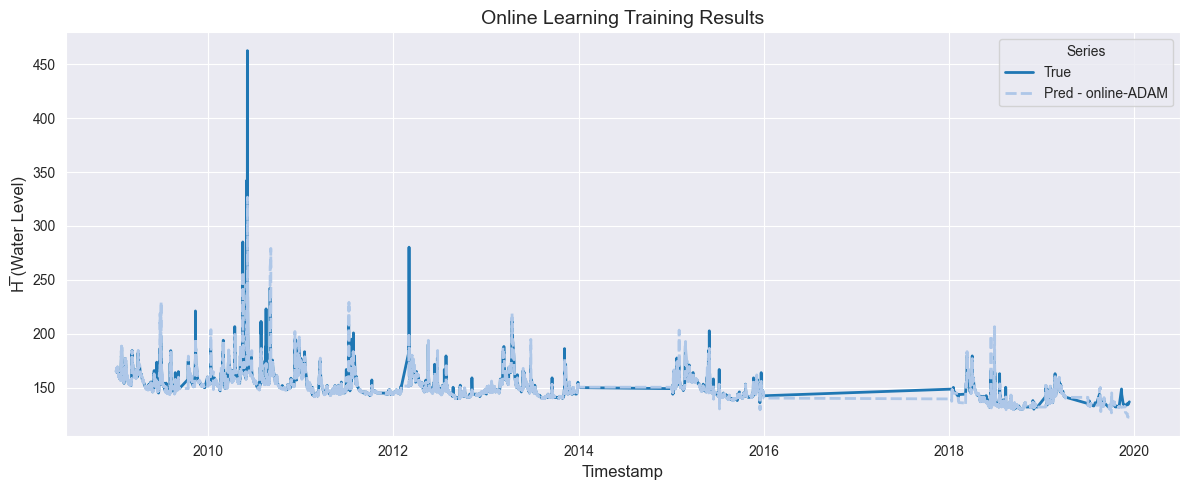

Appended metrics to CSV: results/training\Online Learning Training Results.csv


In [5]:
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)

y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              train_ds, train_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-ADAM": (y_true, y_pred, time_indices)}, 
                              plot_title="Online Learning Training Results",
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/training/Online Learning Training Results')

Testing complete.


============== FINAL COMPARISON ==============
online-ADAM          | RMSE=6.2579 | MAE=1.3930 | R²=0.7037


Saved PNG: results/testing/online\Online Learning MLP test.png


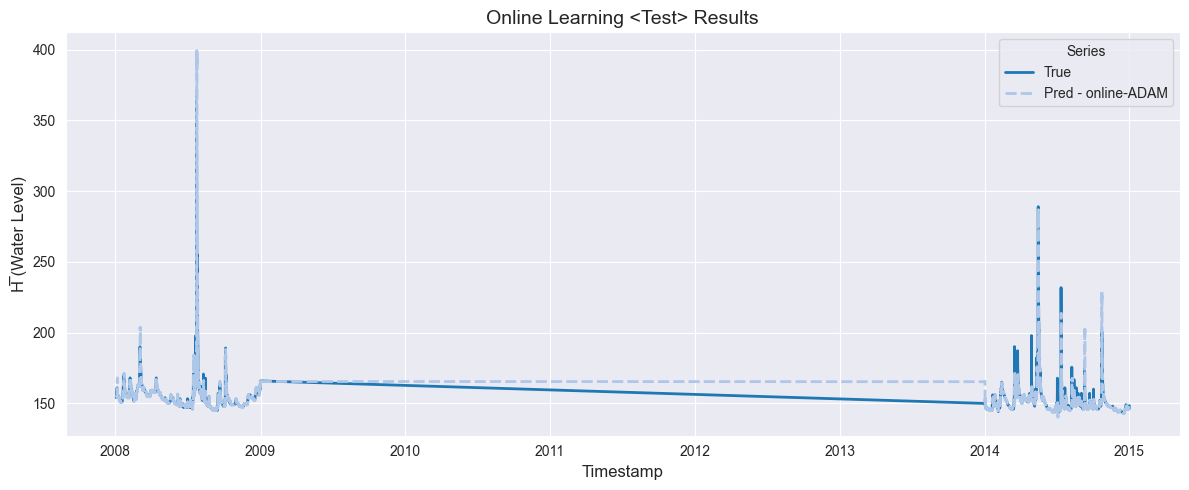

Appended metrics to CSV: results/testing/online\Online Learning MLP test.csv
Exported results to CSV: results/testing/predictions_vs_true/online_MLP.csv


In [6]:
# evaluation on test set
y_true_test, y_pred_test, time_indices_test = uf.model_evaluate_with_norm(model,criterion, test_ds, test_df.index,
                                                                 LOOKBACK, HORIZON, BATCH_SIZE)
uf.calculate_metrics_and_plot({"online-ADAM": (y_true_test, y_pred_test, time_indices_test)},
                              plot_title = 'Online Learning <Test> Results',
                              export_metrics= True,
                              export_html= True,
                              export_file_name='results/testing/online/Online Learning MLP test')
# Save predictions to CSV files to be used later in Experiments
uf.export_results_to_csv({"MLP": (y_true_test, y_pred_test,time_indices_test)}, 
                         "results/testing/predictions_vs_true/online")

## Testing with Online Learning (from data on the fly)


Starting 'online' training with 728 batches...
   Batch 100/728, Loss: 25.300278
   Batch 200/728, Loss: 7.909159
   Batch 300/728, Loss: 0.220805
   Batch 400/728, Loss: 0.530626
   Batch 500/728, Loss: 0.009308
   Batch 600/728, Loss: 0.041758
   Batch 700/728, Loss: 0.040458
   Batch 728/728, Loss: 14.782001
Training complete.


============== FINAL COMPARISON ==============
online-MLP           | RMSE=5.4477 | MAE=1.3041 | R²=0.7755


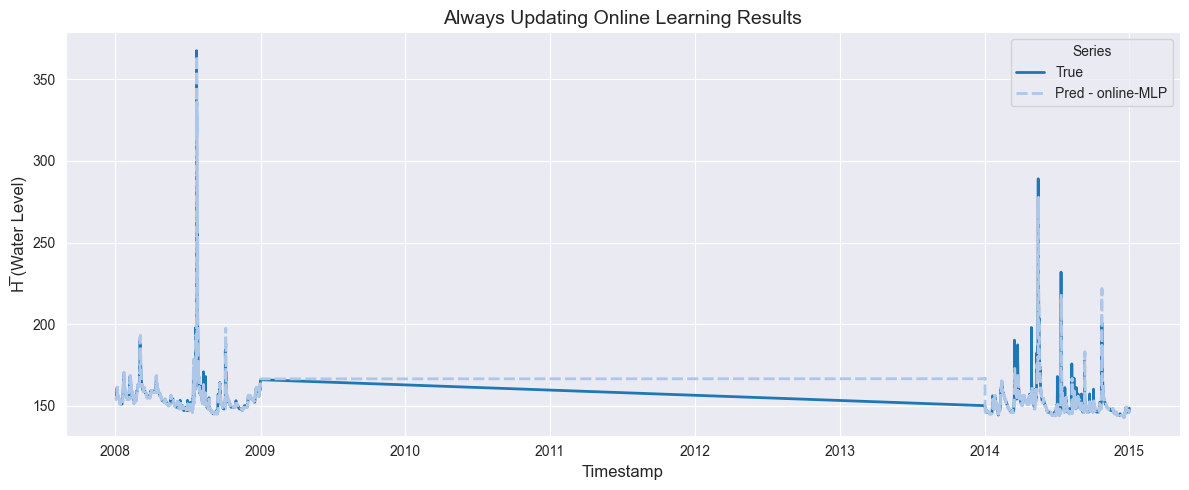

In [7]:
# Testing with always updating 
model, optimizer, criterion = build_mlp(LOOKBACK*N_FEATURES, HORIZON)
y_true, y_pred, time_indices, cutom_adam_batch_losses = uf.train_model_online(model, optimizer,criterion,
                                                                              test_ds, test_df,
                                                                              LOOKBACK, HORIZON, BATCH_SIZE)
#training results
uf.calculate_metrics_and_plot({"online-MLP": (y_true, y_pred, time_indices)}, 
                              plot_title="Always Updating Online Learning Results")

## Normalization with Rolling Norm and Y-clip


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 6.863451
   Batch 200/2461, Loss: 0.164778
   Batch 300/2461, Loss: 0.015847
   Batch 400/2461, Loss: 0.185332
   Batch 500/2461, Loss: 0.066790
   Batch 600/2461, Loss: 0.041006
   Batch 700/2461, Loss: 2.716277
   Batch 800/2461, Loss: 0.118797
   Batch 900/2461, Loss: 21.514914
   Batch 1000/2461, Loss: 2.621945
   Batch 1100/2461, Loss: 0.401841
   Batch 1200/2461, Loss: 0.339996
   Batch 1300/2461, Loss: 0.007741
   Batch 1400/2461, Loss: 2.525888
   Batch 1500/2461, Loss: 0.374728
   Batch 1600/2461, Loss: 1.062764
   Batch 1700/2461, Loss: 0.273070
   Batch 1800/2461, Loss: 0.034370
   Batch 1900/2461, Loss: 5.632747
   Batch 2000/2461, Loss: 0.093106
   Batch 2100/2461, Loss: 1.482132
   Batch 2200/2461, Loss: 0.125537
   Batch 2300/2461, Loss: 0.004624
   Batch 2400/2461, Loss: 0.077271
   Batch 2461/2461, Loss: 2.390426
Training complete.


============== FINAL COMPARISON ==============
RollingNorm+clip

Saved PNG: results/training/online\p1_rolling_clip.png


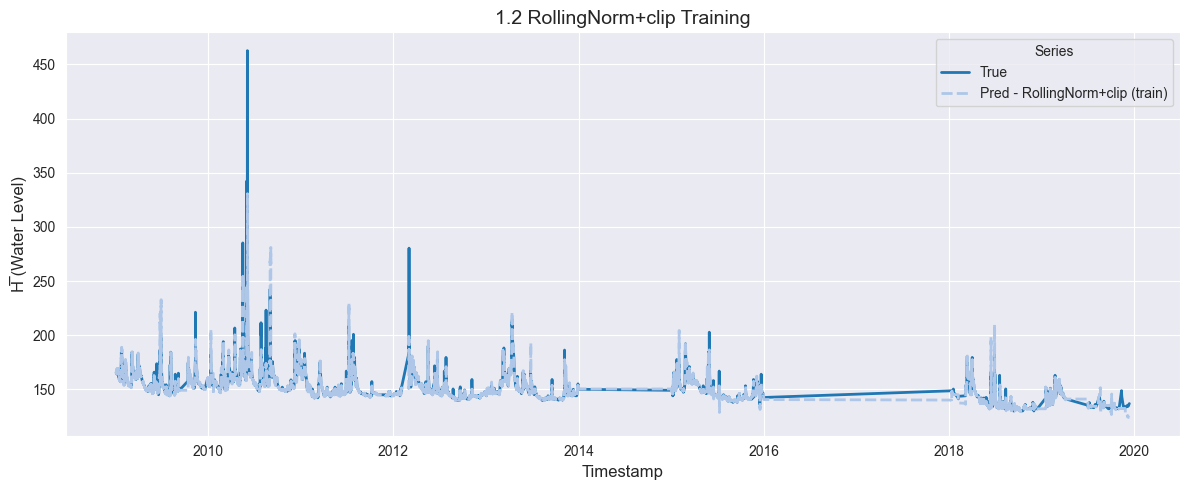

Appended metrics to CSV: results/training/online\p1_rolling_clip.csv


In [8]:
import torch
torch.manual_seed(42)

# RollingNorm with y_scaled clamped to [-5, 5] leak fixed, same Adam baseline
train_ds_roll = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX, y_clip=5.0)
test_ds_roll  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX, y_clip=5.0)

model_roll, opt_roll, crit_roll = build_mlp(LOOKBACK * N_FEATURES, HORIZON)

y_tr_roll, y_pr_roll, idx_roll, losses_roll = uf.train_model_online(
    model_roll, opt_roll, crit_roll,
    train_ds_roll, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
)

uf.calculate_metrics_and_plot(
    {"RollingNorm+clip (train)": (y_tr_roll, y_pr_roll, idx_roll)},
    plot_title="1.2 RollingNorm+clip Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p1_rolling_clip",
)

Testing complete.


============== FINAL COMPARISON ==============
RollingNorm+clip     | RMSE=6.5807 | MAE=1.4476 | R²=0.6724


Saved PNG: results/testing/online\p1_rolling_clip.png


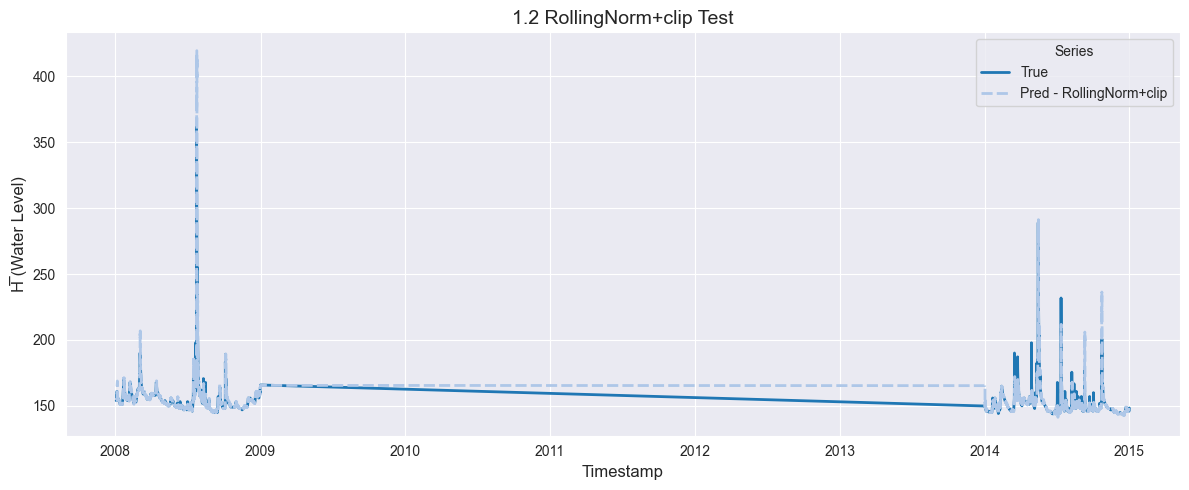

Appended metrics to CSV: results/testing/online\p1_rolling_clip.csv
Exported results to CSV: results/testing/predictions_vs_true/online_RollingNorm_clip.csv


In [9]:
y_te_roll, y_pe_roll, idx_te_roll = uf.model_evaluate_with_norm(
    model_roll, crit_roll, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)

uf.calculate_metrics_and_plot(
    {"RollingNorm+clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    plot_title="1.2 RollingNorm+clip Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p1_rolling_clip",
)
uf.export_results_to_csv(
    {"RollingNorm_clip": (y_te_roll, y_pe_roll, idx_te_roll)},
    "results/testing/predictions_vs_true/online"
)

### Phase 1 winner: RollingNorm+clip — use these for all Phase 2 experiments

In [10]:
BEST_TRAIN_DS = train_ds_roll   # RollingNormTimeSeriesDataset with y_clip=5.0
BEST_TEST_DS  = test_ds_roll    # matching test dataset

## 2A: Model & parameters selection

### RMS-Prop


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 7.114760
   Batch 200/2461, Loss: 0.213834
   Batch 300/2461, Loss: 0.408934
   Batch 400/2461, Loss: 0.151670
   Batch 500/2461, Loss: 0.071825
   Batch 600/2461, Loss: 0.106367
   Batch 700/2461, Loss: 4.225095
   Batch 800/2461, Loss: 0.109014
   Batch 900/2461, Loss: 21.942423
   Batch 1000/2461, Loss: 2.578308
   Batch 1100/2461, Loss: 0.202605
   Batch 1200/2461, Loss: 0.287310
   Batch 1300/2461, Loss: 0.036089
   Batch 1400/2461, Loss: 2.447963
   Batch 1500/2461, Loss: 0.077215
   Batch 1600/2461, Loss: 2.805940
   Batch 1700/2461, Loss: 0.327259
   Batch 1800/2461, Loss: 0.014754
   Batch 1900/2461, Loss: 5.395528
   Batch 2000/2461, Loss: 0.083438
   Batch 2100/2461, Loss: 1.369140
   Batch 2200/2461, Loss: 0.101288
   Batch 2300/2461, Loss: 0.006850
   Batch 2400/2461, Loss: 0.078612
   Batch 2461/2461, Loss: 2.753775
Training complete.


============== FINAL COMPARISON ==============
RMSprop (train) 

Saved PNG: results/training/online\p2_rmsprop.png


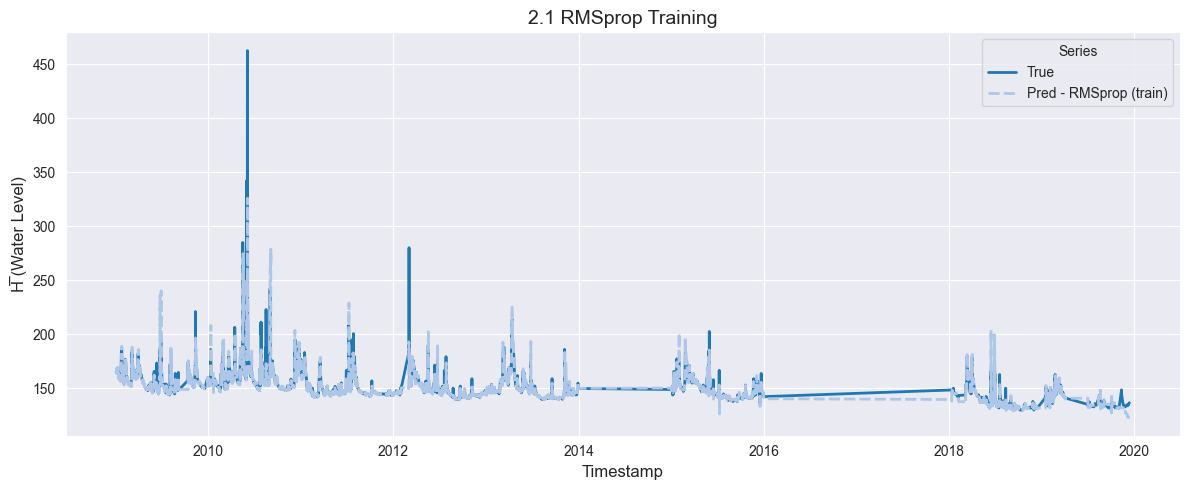

Appended metrics to CSV: results/training/online\p2_rmsprop.csv


In [11]:
import torch.optim as optim
torch.manual_seed(42)

model_rms, _, crit_rms = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_rms = optim.RMSprop(model_rms.parameters(), lr=1e-3, alpha=0.99)

y_tr_rms, y_pr_rms, idx_rms, losses_rms = uf.train_model_online(
    model_rms, opt_rms, crit_rms,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"RMSprop (train)": (y_tr_rms, y_pr_rms, idx_rms)},
    plot_title="2.1 RMSprop Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_rmsprop",
)

Testing complete.


============== FINAL COMPARISON ==============
RMSprop              | RMSE=5.3101 | MAE=1.4089 | R²=0.7867


Saved PNG: results/testing/online\p2_rmsprop.png


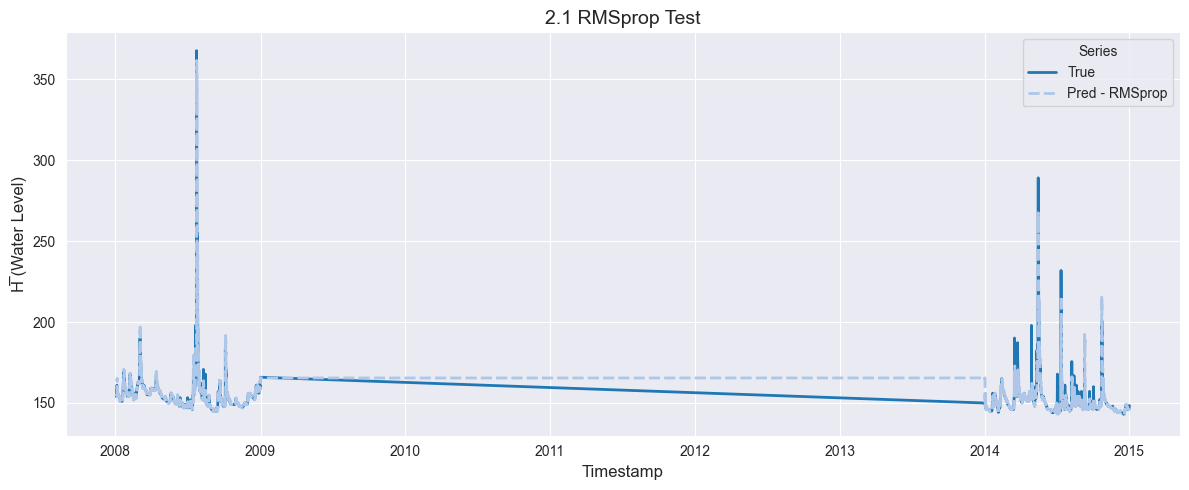

Appended metrics to CSV: results/testing/online\p2_rmsprop.csv
Exported results to CSV: results/testing/predictions_vs_true/online_RMSprop.csv


In [12]:
y_te_rms, y_pe_rms, idx_te_rms = uf.model_evaluate_with_norm(
    model_rms, crit_rms, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"RMSprop": (y_te_rms, y_pe_rms, idx_te_rms)},
    plot_title="2.1 RMSprop Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_rmsprop",
)
uf.export_results_to_csv(
    {"RMSprop": (y_te_rms, y_pe_rms, idx_te_rms)},
    "results/testing/predictions_vs_true/online"
)

### 2- ADAM


Starting 'online' training with 2461 batches...
   Batch 100/2461, Loss: 12.930325
   Batch 200/2461, Loss: 0.049767
   Batch 300/2461, Loss: 0.081062
   Batch 400/2461, Loss: 0.528059
   Batch 500/2461, Loss: 0.108977
   Batch 600/2461, Loss: 0.007924
   Batch 700/2461, Loss: 4.006501
   Batch 800/2461, Loss: 0.014935
   Batch 900/2461, Loss: 23.198851
   Batch 1000/2461, Loss: 2.775992
   Batch 1100/2461, Loss: 3.730363
   Batch 1200/2461, Loss: 0.608595
   Batch 1300/2461, Loss: 0.059999
   Batch 1400/2461, Loss: 1.487908
   Batch 1500/2461, Loss: 0.171964
   Batch 1600/2461, Loss: 1.779627
   Batch 1700/2461, Loss: 1.792355
   Batch 1800/2461, Loss: 0.483494
   Batch 1900/2461, Loss: 5.244813
   Batch 2000/2461, Loss: 0.155965
   Batch 2100/2461, Loss: 1.462313
   Batch 2200/2461, Loss: 0.049141
   Batch 2300/2461, Loss: 0.129880
   Batch 2400/2461, Loss: 0.066475
   Batch 2461/2461, Loss: 2.288364
Training complete.


============== FINAL COMPARISON ==============
Adam-WD (train)

Saved PNG: results/training/online\p2_adam_wd.png


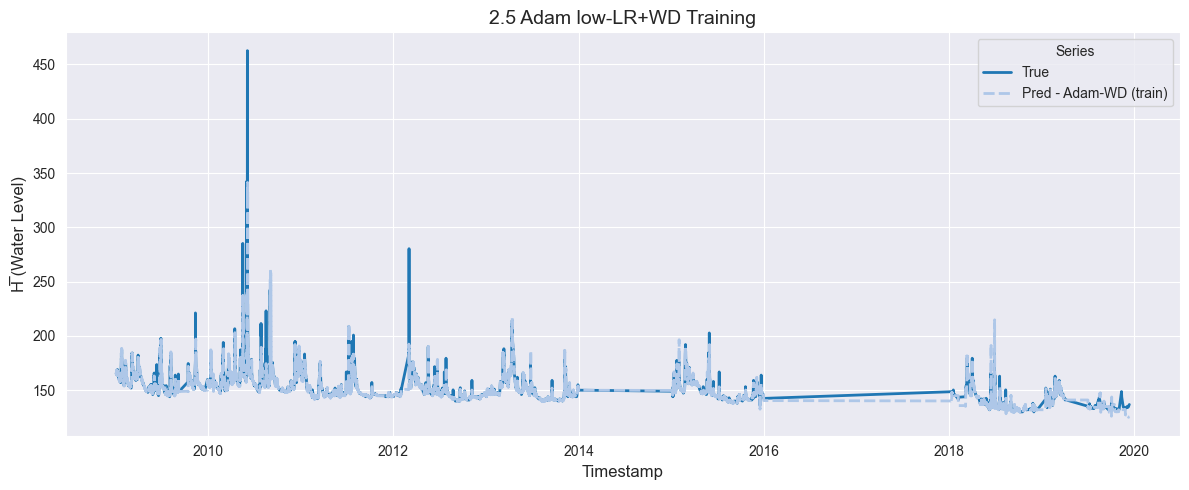

Appended metrics to CSV: results/training/online\p2_adam_wd.csv


In [13]:
torch.manual_seed(42)

model_adamwd, _, crit_adamwd = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
opt_adamwd = optim.Adam(model_adamwd.parameters(), lr=1e-4, weight_decay=1e-4)

y_tr_awd, y_pr_awd, idx_awd, losses_awd = uf.train_model_online(
    model_adamwd, opt_adamwd, crit_adamwd,
    BEST_TRAIN_DS, train_df,
    LOOKBACK, HORIZON, BATCH_SIZE,
    max_grad_norm=1.0,
)

uf.calculate_metrics_and_plot(
    {"Adam-WD (train)": (y_tr_awd, y_pr_awd, idx_awd)},
    plot_title="2.5 Adam low-LR+WD Training",
    export_metrics=True, export_html=True,
    export_file_name="results/training/online/p2_adam_wd",
)

Testing complete.


============== FINAL COMPARISON ==============
Adam-WD              | RMSE=6.9240 | MAE=1.4810 | R²=0.6373


Saved PNG: results/testing/online\p2_adam_wd.png


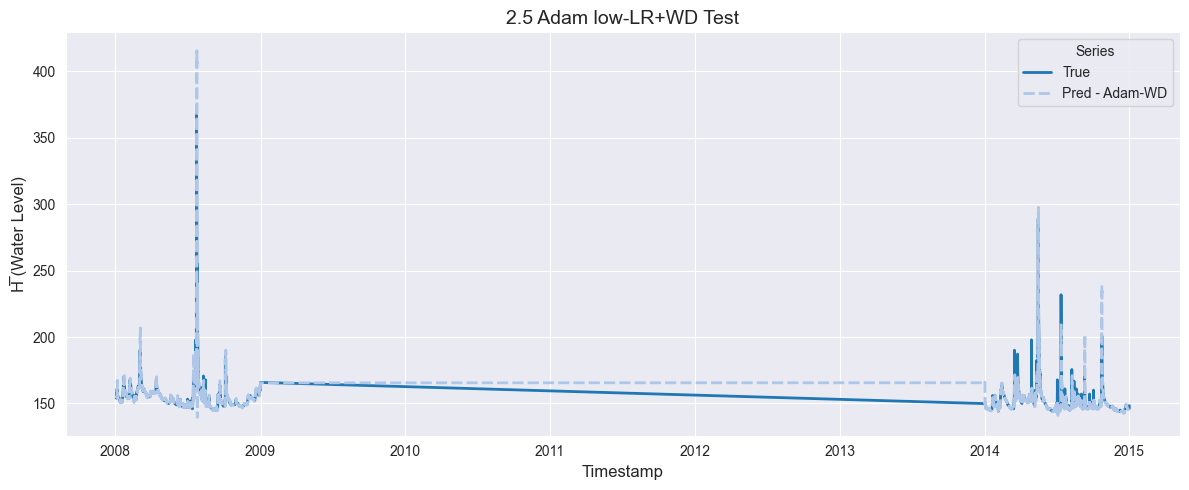

Appended metrics to CSV: results/testing/online\p2_adam_wd.csv
Exported results to CSV: results/testing/predictions_vs_true/online_Adam_WD.csv


In [14]:
y_te_awd, y_pe_awd, idx_te_awd = uf.model_evaluate_with_norm(
    model_adamwd, crit_adamwd, BEST_TEST_DS, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
)
uf.calculate_metrics_and_plot(
    {"Adam-WD": (y_te_awd, y_pe_awd, idx_te_awd)},
    plot_title="2.5 Adam low-LR+WD Test",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/p2_adam_wd",
)
uf.export_results_to_csv(
    {"Adam_WD": (y_te_awd, y_pe_awd, idx_te_awd)},
    "results/testing/predictions_vs_true/online"
)



============== FINAL COMPARISON ==============
RMSprop              | RMSE=5.3101 | MAE=1.4089 | R²=0.7867
Adam-WD              | RMSE=6.9240 | MAE=1.4810 | R²=0.6373


Saved PNG: results/testing/online\phase2_optimizer_comparison.png


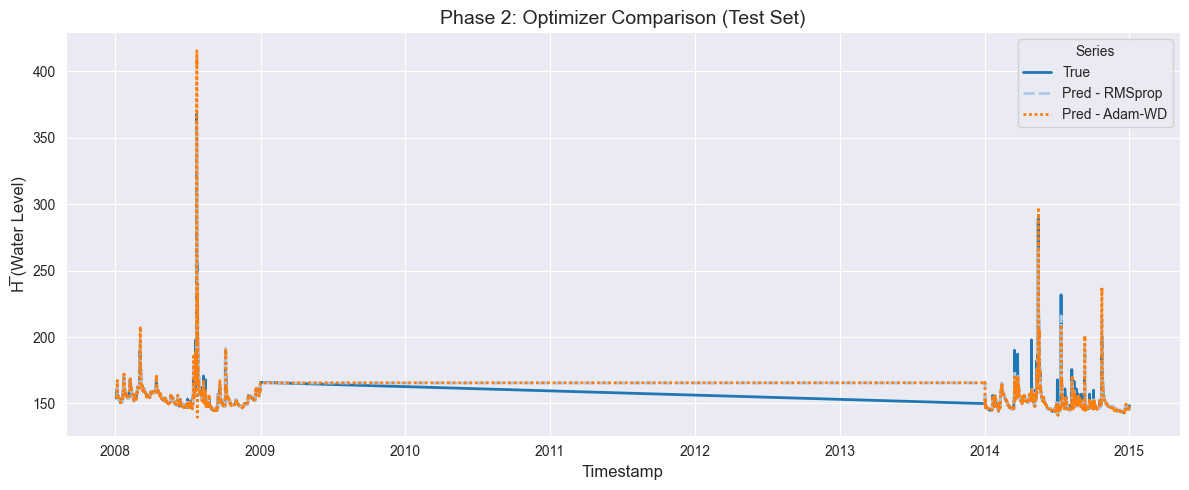

Appended metrics to CSV: results/testing/online\phase2_optimizer_comparison.csv


In [15]:
uf.calculate_metrics_and_plot(
    {
        "RMSprop":    (y_te_rms, y_pe_rms, idx_te_rms),
        "Adam-WD":    (y_te_awd, y_pe_awd, idx_te_awd),
    },
    plot_title="Phase 2: Optimizer Comparison (Test Set)",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/phase2_optimizer_comparison",
)

## 2B: hyperparameters ablation with ADAM

In [16]:
import importlib
import util_fun as uf
importlib.reload(uf)

ADAM_CONFIGS = [
    ("Adam-default",        dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b1=0.7",         dict(lr=1e-3, betas=(0.70, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-b1=0.5",         dict(lr=1e-3, betas=(0.50, 0.999), eps=1e-8,  amsgrad=False)),
    ("Adam-amsgrad",        dict(lr=1e-3, betas=(0.90, 0.999), eps=1e-8,  amsgrad=True)),
    ("Adam-b1=0.5-amsgrad", dict(lr=1e-3, betas=(0.50, 0.900), eps=1e-4,  amsgrad=True)),
]

adam_test_results = {}
for label, kwargs in ADAM_CONFIGS:
    print(f"Running {label}...", end=" ", flush=True)
    torch.manual_seed(42)
    model_a, _, crit_a = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
    opt_a = optim.Adam(model_a.parameters(), **kwargs)

    uf.train_model_online(
        model_a, opt_a, crit_a,
        train_ds_roll, train_df,
        LOOKBACK, HORIZON, BATCH_SIZE,
        max_grad_norm=1.0, silent=True,
    )
    y_te_a, y_pe_a, idx_te_a = uf.model_evaluate_with_norm(
        model_a, crit_a, test_ds_roll, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
    )
    adam_test_results[label] = (y_te_a, y_pe_a, idx_te_a)
    uf.export_results_to_csv({label: (y_te_a, y_pe_a, idx_te_a)},
                             "results/testing/predictions_vs_true/online")
    print("done.")

print("\nAll Adam configs done.")

Running Adam-default... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-default.csv
done.
Running Adam-b1=0.7... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.7.csv
done.
Running Adam-b1=0.5... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.5.csv
done.
Running Adam-amsgrad... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-amsgrad.csv
done.
Running Adam-b1=0.5-amsgrad... Testing complete.
Exported results to CSV: results/testing/predictions_vs_true/online_Adam-b1=0.5-amsgrad.csv
done.

All Adam configs done.


## 2C: FTRL (Follow The Regularized Leader) --> best with concept drift

# Fixed pipeline — scale floor + honest evaluation

**Why:** the sections above use the legacy pipeline, whose metrics are inflated:

- `y_clip=5.0` bound on **~9% of targets** (flat 48h lookbacks give std ≈ 0, so `y_scaled` explodes and gets clamped). It censored flood peaks — e.g. 2008-07-23 real level **301.67** entered training/eval as **216.13**.
- Train/eval reconstructed "ground truth" from the **clipped** target, so all exported metrics were scored against softened truth: FTRL-default's reported RMSE 3.44 / R² 0.901 is **4.84 / 0.823** against the real gauge (+40% RMSE).
- `max_grad_norm=1.0` was passed only in Phase 2 runs (confound vs the Phase 1 baseline).

**Fixes (now in `util_fun.py`):**
1. `scale_floor` — train-derived constant (q0.15 of train-window stds ≈ 0.095) floors the normalization denominator; degenerate windows fixed, healthy windows untouched.
2. Datasets return raw `y`; train/eval score against **real observations**, never the clipped reconstruction.
3. `y_clip=500` = pure tripwire — genuine flood onsets reach 10–80σ, so the clamp must sit far above real dynamics; `report_y_clip_binding` verifies **0%** binding.
4. `max_grad_norm=1.0` is now the default for every run.

Standalone reproduction: `rerun_fixed_pipeline.py`. Its output (RMSE / R²):

| model | old reported | old honest | **fixed pipeline** |
|---|---|---|---|
| FTRL-default | 3.438 / 0.901 | 4.835 / 0.823 | **4.836 / 0.823** |
| RMSprop | 4.087 / 0.860 | 5.310 / 0.787 | **5.702 / 0.754** |
| Adam-default | 5.662 / 0.731 | 6.581 / 0.672 | **6.224 / 0.707** |

Ranking unchanged (FTRL still wins); the fixed column is the first number trained *and* scored on uncensored data.

In [17]:
# Fixed-pipeline datasets (standalone version: rerun_fixed_pipeline.py)
import os
os.makedirs("results/testing/online_fixed", exist_ok=True)

Y_CLIP_TRIPWIRE = 500.0   # far above genuine dynamics (train max |y_scaled| ~122 with floor)
scale_floor = uf.compute_scale_floor(x_train, H_BAR_INDEX, quantile=0.15)

train_ds_fixed = uf.RollingNormTimeSeriesDataset(x_train, y_train, H_BAR_INDEX,
                                                 y_clip=Y_CLIP_TRIPWIRE, scale_floor=scale_floor)
test_ds_fixed  = uf.RollingNormTimeSeriesDataset(x_test,  y_test,  H_BAR_INDEX,
                                                 y_clip=Y_CLIP_TRIPWIRE, scale_floor=scale_floor)

# tripwire: must be 0% — if it ever binds, the data is wilder than anything in train
uf.report_y_clip_binding(train_ds_fixed, "train")
uf.report_y_clip_binding(test_ds_fixed, "test")

scale_floor = 0.094705 (q0.15 of 2461 train-window stds; median 0.5635)
y_clip binding [train]: 0/59064 elements (0.0000%)
y_clip binding [test]: 0/17472 elements (0.0000%)


0.0

Running Adam-default... Testing complete.
Exported results to CSV: results/testing/online_fixed/online_fixed_Adam-default.csv
Running RMSprop... Testing complete.
Exported results to CSV: results/testing/online_fixed/online_fixed_RMSprop.csv
Running FTRL-default... Testing complete.
Exported results to CSV: results/testing/online_fixed/online_fixed_FTRL-default.csv


============== FINAL COMPARISON ==============
Adam-default         | RMSE=6.2237 | MAE=1.3996 | R²=0.7069
RMSprop              | RMSE=5.7019 | MAE=1.4025 | R²=0.7540
FTRL-default         | RMSE=4.8361 | MAE=1.3437 | R²=0.8231


Saved PNG: results/testing/online\fixed_pipeline_comparison.png


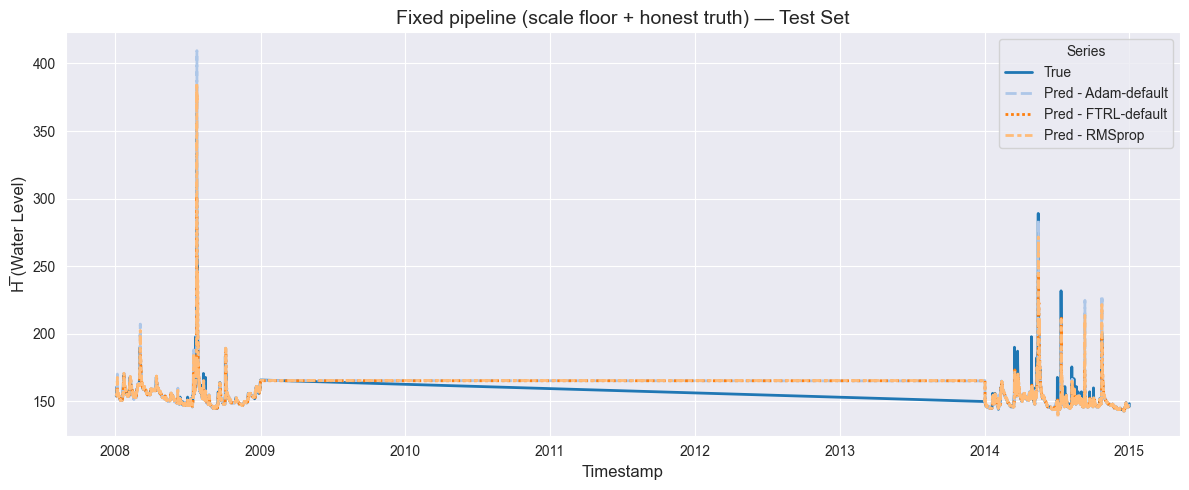

Appended metrics to CSV: results/testing/online\fixed_pipeline_comparison.csv


In [18]:
# Re-run the headline models on the fixed pipeline (honest truth, grad clip everywhere)
import torch.optim as optim
from cstm_models.ftrl import FTRL

fixed_results = {}
for label, make_opt in [
    ("Adam-default", lambda m: optim.Adam(m.parameters(), lr=1e-3)),
    ("RMSprop",      lambda m: optim.RMSprop(m.parameters(), lr=1e-3, alpha=0.99)),
    ("FTRL-default", lambda m: FTRL(m.parameters(), alpha=0.01, beta=1.0, lambda1=0.0, lambda2=0.0)),
]:
    print(f"Running {label}...", end=" ", flush=True)
    torch.manual_seed(42)
    model_f, _, crit_f = build_mlp(LOOKBACK * N_FEATURES, HORIZON)
    opt_f = make_opt(model_f)

    uf.train_model_online(model_f, opt_f, crit_f, train_ds_fixed, train_df,
                          LOOKBACK, HORIZON, BATCH_SIZE, silent=True)  # max_grad_norm=1.0 is default now
    y_te_f, y_pe_f, idx_te_f = uf.model_evaluate_with_norm(
        model_f, crit_f, test_ds_fixed, test_df.index, LOOKBACK, HORIZON, BATCH_SIZE
    )
    fixed_results[label] = (y_te_f, y_pe_f, idx_te_f)
    uf.export_results_to_csv({label: (y_te_f, y_pe_f, idx_te_f)},
                             "results/testing/online_fixed/online_fixed")

uf.calculate_metrics_and_plot(
    fixed_results,
    plot_title="Fixed pipeline (scale floor + honest truth) — Test Set",
    export_metrics=True, export_html=True,
    export_file_name="results/testing/online/fixed_pipeline_comparison",
)